# Purpose

Show that adding cell type profiles to model increases performance

In [201]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc
from scipy.stats import spearmanr

In [202]:
def load_expansion_data(
    path_to_boot = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/expansionSimulation/results/allcts_reallabels",
    path_to_mgcs = '/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/analysis/PaperFigs/MGC/data/mgc_gini_all.csv'
) -> pd.DataFrame:

    lo_boots = np.array(os.listdir(path_to_boot))
    lo_boots = np.sort(lo_boots.astype(int))
    lo_boot_paths = [f'{path_to_boot}/{boot}' for boot in lo_boots]
    lo_egads = os.listdir(f"{path_to_boot}/1/EGAD")

    lo_egads_paths = [f'{boot_path}/EGAD/{egad}' for boot_path in lo_boot_paths for egad in lo_egads]
    lo_dfs = [pd.read_csv(path) for path in lo_egads_paths]
    lo_ncts_for_df = [string.split("/")[-1].split("_")[0] for string in lo_egads_paths]
    lo_boots_for_df = [string.split("/")[-3] for string in lo_egads_paths]

    lo_dfs_meta = []
    for i, df in enumerate(lo_dfs):
        df['nct'] = lo_ncts_for_df[i]
        df['boot'] = lo_boots_for_df[i]
        lo_dfs_meta.append(df)

    all_dfs_concat = pd.concat(lo_dfs_meta, axis=0).reset_index()
    graph_dfs = all_dfs_concat.groupby(['nct', 'index'])['auc'].mean().reset_index()
    graph_dfs['nct'] = pd.to_numeric(graph_dfs['nct'])

    mgcs = pd.read_csv(path_to_mgcs, index_col=0).reset_index()
    mgcs.columns = ['id', 'mgc_gini']
    graph_with_meta = graph_dfs.merge(mgcs, left_on='index', right_on='id')

    return graph_with_meta

graph_dfs_mean_cta = load_expansion_data()
graph_dfs_mean_cta.head()

,nct,index,auc,id,mgc_gini
0,10,GO:0000045,0.534301,GO:0000045,0.476276
1,15,GO:0000045,0.535731,GO:0000045,0.476276
2,20,GO:0000045,0.523993,GO:0000045,0.476276
3,25,GO:0000045,0.522348,GO:0000045,0.476276
4,30,GO:0000045,0.525312,GO:0000045,0.476276


In [203]:
# def fit_model_expansion(graph_dfs_mean_cta:pd.DataFrame):    
#     model = smf.ols('auc ~ nct*CTAffiliated + log*CTAffiliated', data=graph_dfs_mean_cta).fit()
#     return model

def fit_model_expansion(graph_dfs_mean_cta:pd.DataFrame):    
    model = smf.mixedlm('auc ~ log_nct*mgc_gini', data=graph_dfs_mean_cta, groups=graph_dfs_mean_cta["index"]).fit()
    return model

graph_dfs_mean_cta['log_nct'] = np.log(graph_dfs_mean_cta['nct'])
model_expansion = fit_model_expansion(graph_dfs_mean_cta=graph_dfs_mean_cta)
model_expansion.summary()

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM  Dependent Variable:  auc       
No. Observations:   23732    Method:              REML      
No. Groups:         1396     Scale:               0.0004    
Min. group size:    17       Log-Likelihood:      54482.2848
Max. group size:    17       Converged:           Yes       
Mean group size:    17.0                                    
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         0.562    0.007  77.349 0.000  0.548  0.577
log_nct          -0.015    0.001 -20.139 0.000 -0.016 -0.013
mgc_gini         -0.101    0.011  -9.509 0.000 -0.121 -0.080
log_nct:mgc_gini  0.059    0.001  55.764 0.000  0.057  0.061
Group Var         0.004    0.007                            
============================================================

"""

In [204]:
graph_dfs_mean_cta

,nct,index,auc,id,mgc_gini,log_nct
0,10,GO:0000045,0.534301,GO:0000045,0.476276,2.302585
1,15,GO:0000045,0.535731,GO:0000045,0.476276,2.708050
2,20,GO:0000045,0.523993,GO:0000045,0.476276,2.995732
3,25,GO:0000045,0.522348,GO:0000045,0.476276,3.218876
4,30,GO:0000045,0.525312,GO:0000045,0.476276,3.401197
...,...,...,...,...,...,...
23727,65,GO:2001244,0.553388,GO:2001244,0.543192,4.174387
23728,70,GO:2001244,0.552362,GO:2001244,0.543192,4.248495
23729,75,GO:2001244,0.557365,GO:2001244,0.543192,4.317488
23730,80,GO:2001244,0.558578,GO:2001244,0.543192,4.382027


In [205]:
model_expansion.pvalues

Intercept            0.000000e+00
log_nct              3.383599e-90
mgc_gini             1.920555e-21
log_nct:mgc_gini     0.000000e+00
Group Var           8.495363e-143
dtype: float64

In [206]:
graph_dfs_mean_cta_grouped = graph_dfs_mean_cta.groupby(['nct', 'mgc_gini'])['auc'].mean().reset_index()
graph_dfs_mean_cta_grouped['log_nct'] = np.log(graph_dfs_mean_cta_grouped['nct'])
graph_dfs_mean_cta_grouped['prediction'] = model_expansion.predict(graph_dfs_mean_cta_grouped)

In [207]:
import os
os.makedirs('results', exist_ok=True)

def fit_model_ols(graph_dfs_mean_cta:pd.DataFrame):    
    model = smf.ols('auc ~ log_nct*mgc_gini', data=graph_dfs_mean_cta).fit()
    return model

model_ols = fit_model_ols(graph_dfs_mean_cta=graph_dfs_mean_cta_grouped)

# Save model summaries
with open("results/mixedlm_summary.txt", "w") as f:
    f.write(str(model_expansion.summary()))

with open("results/ols_summary.txt", "w") as f:
    f.write(str(model_ols.summary()))

model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    auc   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1346.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        18:39:32   Log-Likelihood:                 29437.
No. Observations:               22423   AIC:                        -5.887e+04
Df Residuals:                   22419   BIC:                        -5.883e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.5625      0.008     66.814      0.000       0.546       0.579
log_nct             -0.0141      0.002     -6.113      0.000      -0.019      -0.010
mgc_gini            -0.1010      0.012     -8.237      0.000      -0.125      -0.077
log_nct:mgc_gini     0.0586      0.003     17.497      0.000       0.052       0.065
==============================================================================
Omnibus:                     2591.417   Durbin-Watson:                   1.746
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4228.060
Skew:                           0.815   Prob(JB):                         0.00
Kurtosis:                       4.366   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [208]:
from scipy import stats as scipy_stats
import patsy

# Categorical gini_level: quartiles (Q1–Q4)
graph_dfs_mean_cta['gini_level'] = pd.qcut(
    graph_dfs_mean_cta['mgc_gini'],
    q=4,
    labels=['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)']
)

def fit_model_mixedlm_cat(df):
    return smf.mixedlm(
        'auc ~ log_nct * gini_level',
        data=df,
        groups=df['index']
    ).fit()

model_cat = fit_model_mixedlm_cat(graph_dfs_mean_cta)

# Prediction grid — one row per nct per gini_level
gini_labels_cat = ['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)']
nct_grid_cat = np.linspace(graph_dfs_mean_cta['nct'].min(), graph_dfs_mean_cta['nct'].max(), 100)

pred_df_cat = pd.concat([
    pd.DataFrame({'nct': nct_grid_cat, 'log_nct': np.log(nct_grid_cat), 'gini_level': lbl})
    for lbl in gini_labels_cat
]).reset_index(drop=True)
pred_df_cat['gini_level'] = pd.Categorical(pred_df_cat['gini_level'], categories=gini_labels_cat, ordered=True)

pred_df_cat['auc_hat'] = model_cat.predict(pred_df_cat)

# 95% CI on the fixed-effects mean (model uncertainty)
X_pred = np.asarray(patsy.build_design_matrices([model_cat.model.data.design_info], pred_df_cat)[0])
fe_names = model_cat.fe_params.index
cov_fe = model_cat.cov_params().loc[fe_names, fe_names].values
se = np.sqrt(np.diag(X_pred @ cov_fe @ X_pred.T))
z = scipy_stats.norm.ppf(0.975)
pred_df_cat['ci_low'] = pred_df_cat['auc_hat'] - z * se
pred_df_cat['ci_high'] = pred_df_cat['auc_hat'] + z * se



/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.


In [209]:
import os
os.makedirs('results', exist_ok=True)

# Save fixed-effect coefficients of the quartile mixed model
coef_df = pd.DataFrame({
    'coef': model_cat.fe_params,
    'std_err': model_cat.bse_fe,
    'z': model_cat.tvalues,
    'p_value': model_cat.pvalues[model_cat.fe_params.index],
    'ci_low': model_cat.conf_int().loc[model_cat.fe_params.index, 0],
    'ci_high': model_cat.conf_int().loc[model_cat.fe_params.index, 1],
})
coef_df.index.name = 'term'
coef_df.to_csv('results/mixedlm_quartile_coefficients.csv')
coef_df

,coef,std_err,z,p_value,ci_low,ci_high
term,,,,,,
Group Var,NaN,NaN,25.424005,NaN,NaN,NaN
Intercept,0.510869,0.003455,147.875019,0.000000e+00,0.504098,0.517641
gini_level[T.Q2 (25-50%)],-0.004051,0.004886,-0.829215,4.069829e-01,-0.013627,0.005525
gini_level[T.Q3 (50-75%)],-0.013779,0.004886,-2.820344,4.797216e-03,-0.023355,-0.004204
gini_level[T.Q4 (75-100%)],-0.044138,0.004886,-9.033998,1.655120e-19,-0.053714,-0.034562
log_nct,0.015505,0.000347,44.649941,0.000000e+00,0.014824,0.016185
log_nct:gini_level[T.Q2 (25-50%)],-0.000124,0.000491,-0.251667,8.012982e-01,-0.001086,0.000839
log_nct:gini_level[T.Q3 (50-75%)],0.010114,0.000491,20.595257,3.026801e-94,0.009152,0.011077
log_nct:gini_level[T.Q4 (75-100%)],0.026965,0.000491,54.909596,0.000000e+00,0.026003,0.027928


In [210]:
# def plot_lineplot(graph_dfs_mean_cta_grouped, model_ols):
#     import os
#     os.makedirs('figs', exist_ok=True)

#     plt.figure(figsize=(6, 4))
#     sns.set(style="white")
#     sns.set_context("paper", font_scale=1.6)

#     df = graph_dfs_mean_cta_grouped.copy()
#     df['gini_level'] = pd.qcut(
#         df['mgc_gini'],
#         q=[0, 0.33, 0.67, 1.0],
#         labels=['Low Specificity', 'Mid Specificity', 'High Specificity']
#     )
#     df['prediction'] = model_ols.predict(df)

#     sns.lineplot(data=df, x="nct", y='prediction', hue="gini_level")
#     sns.scatterplot(data=df, x="nct", y='auc', hue="gini_level", legend=False, alpha=0.2, s=8)

#     plt.xlabel("Number of Cell Type Profiles")
#     plt.ylabel("Learnability (AUROC)")
#     plt.legend(title="MGC Gini")
#     sns.despine()
#     plt.tight_layout()
#     plt.savefig('figs/performance_vs_ct_breadth.png', dpi=300, bbox_inches='tight')
#     plt.savefig('figs/performance_vs_ct_breadth.svg', dpi=300, bbox_inches='tight')

# plot_lineplot(graph_dfs_mean_cta_grouped=graph_dfs_mean_cta_grouped, model_ols=model_ols)

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: figs/expansion_model_predictions.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: figs/expansion_model_predictions.pdf


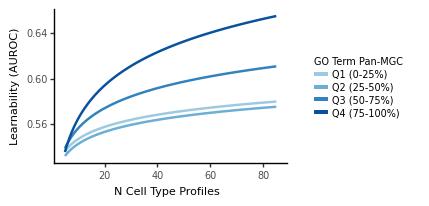

<ggplot: (8759066413153)>

In [211]:
from plotnine import (
    ggplot, aes, geom_line, geom_ribbon, labs, theme_classic,
    theme, element_text, element_rect, scale_color_brewer, scale_fill_brewer, ggsave
)
from plotnine import scale_color_manual, scale_fill_manual
import os
os.makedirs('results', exist_ok=True)
os.makedirs('figs', exist_ok=True)

pred_df_cat.to_csv('results/expansion_predictions.csv', index=False)
from mizani.palettes import brewer_pal

# Get Blues palette and skip the lightest color
blues = brewer_pal(type='seq', palette='Blues')(6)[2:]

p = (
    ggplot(pred_df_cat, aes(x='nct', y='auc_hat',
                            color='gini_level',
                            fill='gini_level'))
    + geom_line(size=1)
    + scale_color_manual(values=blues)
    + scale_fill_manual(values=blues)
    + labs(
        x='N Cell Type Profiles',
        y='Learnability (AUROC)',
        color='GO Term Pan-MGC',
        fill='GO Term Pan-MGC'
    )
    + theme_classic()
    + theme(
        axis_title=element_text(size=8),
        axis_text=element_text(size=7),
        legend_title=element_text(size=7),
        legend_text=element_text(size=7),
        legend_key_size=6,
        legend_key_width=10,
        figure_size=(3, 2)
    )
)

ggsave(p, 'figs/expansion_model_predictions.png', dpi=300)
ggsave(p, 'figs/expansion_model_predictions.pdf')
p